# 01 - ETH/USD Returns and Volatility: Statistical Properties

Research notebook only - nothing here is production logic; the real implementations live in `quant/src/askgene_quant/`. This notebook loads real ETH/USD daily data (Coinbase Exchange, cached locally) and looks at the statistical properties that motivate using GARCH and EWMA rather than a constant-volatility model: fat tails, volatility clustering, and the gap between simple rolling volatility and decay-weighted estimators.

In [1]:
import sys
from pathlib import Path

QUANT_SRC = Path("../quant/src").resolve()
sys.path.insert(0, str(QUANT_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from askgene_quant.config import DEFAULT_VOLATILITY_SETTINGS as settings
from askgene_quant.data.loader import load_market_data
from askgene_quant.data.quality import check_data_quality
from askgene_quant.data.returns import log_returns

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ASSET = "ETH-USD"
ohlcv = load_market_data(ASSET, cache_dir=(QUANT_SRC.parent / "data_cache"))
report = check_data_quality(ohlcv)
print(f"{len(ohlcv)} daily candles, {ohlcv.index.min().date()} -> {ohlcv.index.max().date()}")
print("quality errors:", report.errors or "none")
print(f"quality warnings: {len(report.warnings)}")
for w in report.warnings:
    print(" -", w)

returns = log_returns(ohlcv["close"])
print(f"\n{len(returns)} daily log returns")


3788 daily candles, 2016-05-18 -> 2026-10-02
quality errors: none
quality warnings: 2
 - 2 missing date(s) in expected D calendar between 2016-05-18 and 2026-10-02
 - 1 day(s) with |log return| > 0.5: 2020-03-12

3787 daily log returns


## Price history and daily log returns

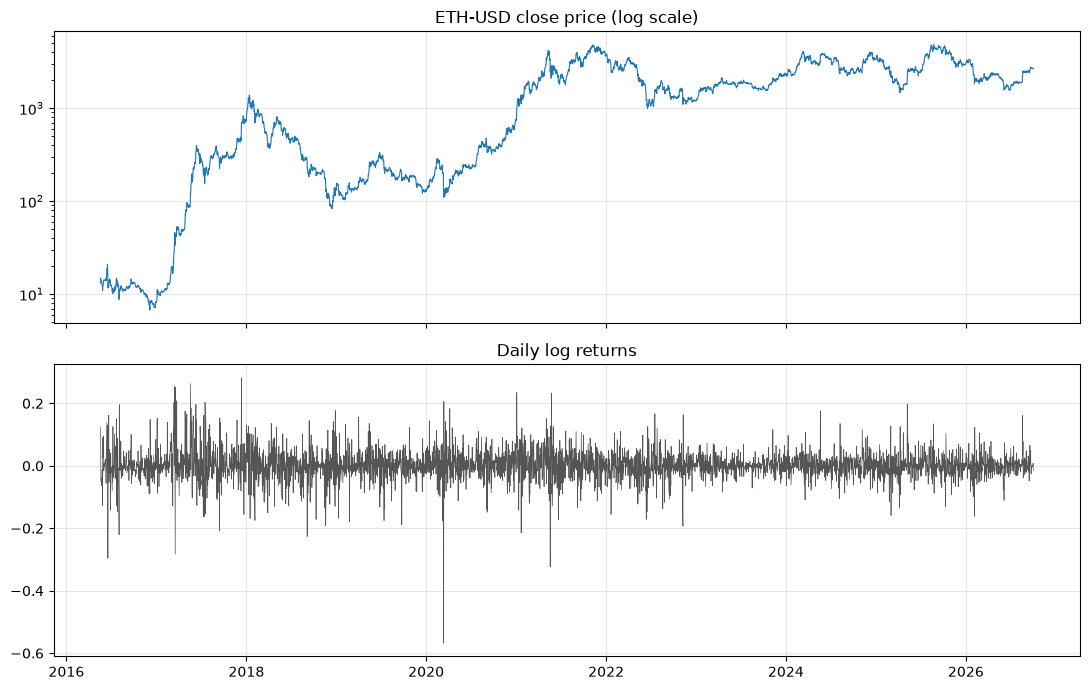

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ohlcv.index, ohlcv["close"], lw=0.8, color="#1f77b4")
axes[0].set_yscale("log")
axes[0].set_title(f"{ASSET} close price (log scale)")
axes[1].plot(returns.index, returns, lw=0.5, color="#555")
axes[1].set_title("Daily log returns")
plt.tight_layout()
plt.show()

## Return distribution

r_t = log(P_t / P_{t-1}). If returns were normally distributed, skewness would be ~0 and (excess) kurtosis ~0. Crypto returns are well known to have fat tails; we check that directly.

In [3]:
from scipy import stats

mean, std, skew, kurt = returns.mean(), returns.std(), returns.skew(), returns.kurtosis()
jb_stat, jb_p = stats.jarque_bera(returns)
print(f"mean:      {mean:.6f}  (~{mean*365:.1%} annualized drift)")
print(f"std:       {std:.6f}  (~{std*np.sqrt(365):.1%} annualized vol)")
print(f"skew:      {skew:.3f}")
print(f"kurtosis:  {kurt:.3f}  (excess; 0 = normal)")
print(f"Jarque-Bera: stat={jb_stat:.1f}, p={jb_p:.2e}  (rejects normality)")

mean:      0.001402  (~51.2% annualized drift)
std:       0.048711  (~93.1% annualized vol)
skew:      -0.390
kurtosis:  9.480  (excess; 0 = normal)
Jarque-Bera: stat=14235.1, p=0.00e+00  (rejects normality)


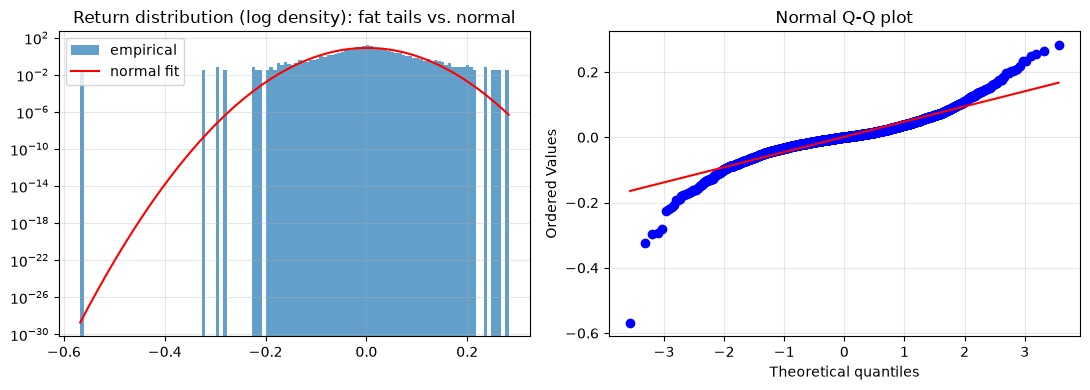

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(returns, bins=120, density=True, alpha=0.7, label="empirical")
x = np.linspace(returns.min(), returns.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mean, std), "r-", lw=1.5, label="normal fit")
axes[0].set_yscale("log")
axes[0].set_title("Return distribution (log density): fat tails vs. normal")
axes[0].legend()

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()
plt.show()

The Q-Q plot's S-shape and the log-density histogram's heavier-than-normal tails are the textbook signature of fat-tailed crypto returns - large moves (in both directions) are far more common than a normal distribution with the same variance would predict.

## Volatility clustering

GARCH exists because volatility isn't i.i.d.: large moves tend to be followed by large moves (of either sign). We check this via the autocorrelation of squared returns (a standard proxy for volatility) versus the autocorrelation of raw returns.

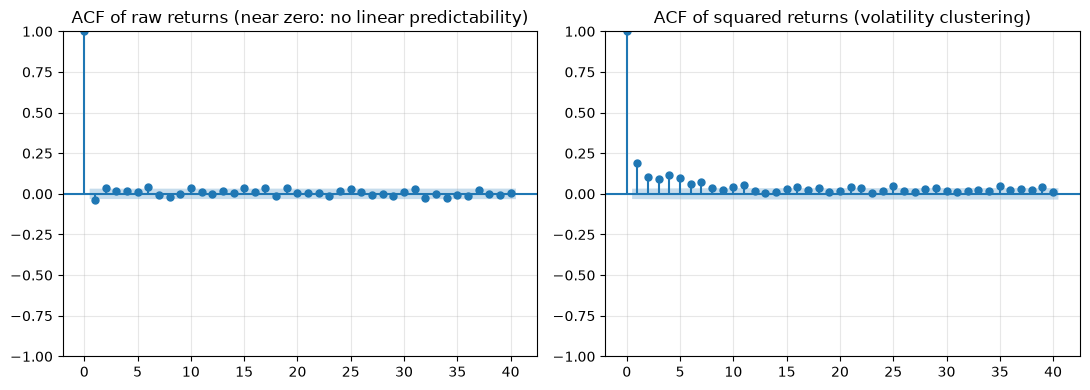

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_acf(returns, lags=40, ax=axes[0])
axes[0].set_title("ACF of raw returns (near zero: no linear predictability)")
plot_acf(returns**2, lags=40, ax=axes[1])
axes[1].set_title("ACF of squared returns (volatility clustering)")
plt.tight_layout()
plt.show()

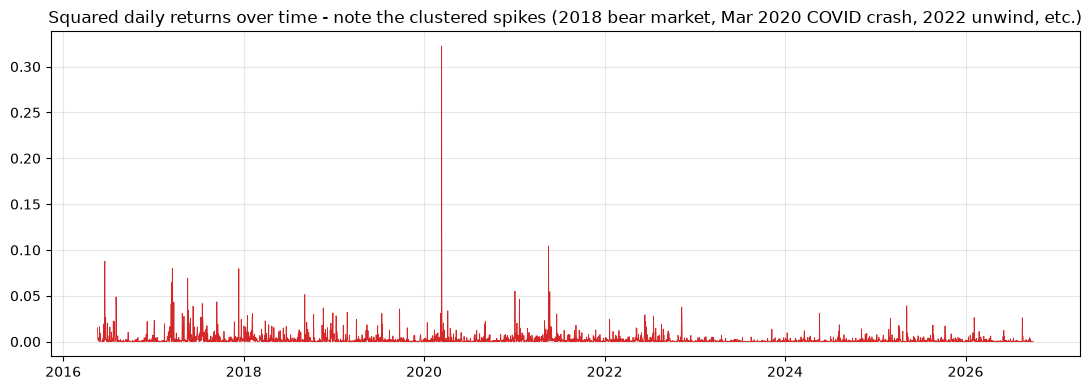

In [6]:
fig, ax = plt.subplots()
ax.plot(returns.index, returns**2, lw=0.6, color="#d62728")
ax.set_title("Squared daily returns over time - note the clustered spikes "
             "(2018 bear market, Mar 2020 COVID crash, 2022 unwind, etc.)")
plt.tight_layout()
plt.show()

## Realized (rolling) volatility vs. EWMA

Rolling volatility treats every observation in the window equally and drops old observations abruptly ("ghosting"). EWMA instead decays old observations smoothly, which should track regime changes faster without the box-car artifacts.

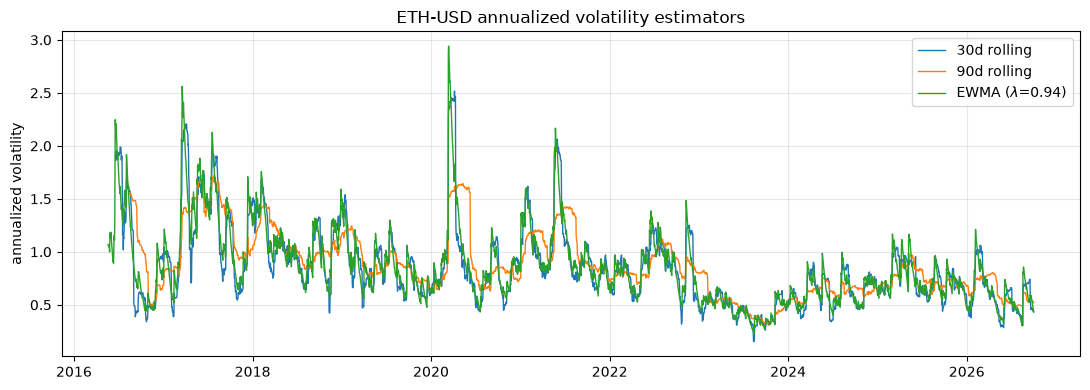

In [7]:
from askgene_quant.volatility.realized import rolling_volatility
from askgene_quant.volatility.ewma import ewma_volatility

rv_30 = rolling_volatility(returns, window=30)
rv_90 = rolling_volatility(returns, window=90)
ewma_vol = ewma_volatility(returns, lam=settings.ewma_lambda)

fig, ax = plt.subplots()
ax.plot(rv_30.index, rv_30, label="30d rolling", lw=1)
ax.plot(rv_90.index, rv_90, label="90d rolling", lw=1)
ax.plot(ewma_vol.index, ewma_vol, label=f"EWMA ($\\lambda$={settings.ewma_lambda})", lw=1)
ax.set_title(f"{ASSET} annualized volatility estimators")
ax.set_ylabel("annualized volatility")
ax.legend()
plt.tight_layout()
plt.show()

EWMA visibly reacts faster to volatility spikes (e.g. sharp drawdowns) than the 90-day rolling window, and unlike the 30-day window it doesn't exhibit sudden level shifts when an old extreme observation rolls out of the trailing window - exactly the motivation for using a decay-weighted estimator (and, going further, GARCH) instead of a plain rolling window. GARCH is explored in `02_garch_analysis.ipynb`.